In [11]:
import time
import csv
import logging
from datetime import datetime

In [12]:
documentos = [
    {
        "tema": "asistencia",
        "contenido": "La asistencia mínima requerida para aprobar una asignatura es 70%."
    },
    {
        "tema": "matricula",
        "contenido": "La matrícula debe realizarse dentro de las fechas establecidas por la institución."
    },
    {
        "tema": "retiro",
        "contenido": "El retiro de asignaturas puede solicitarse dentro del plazo académico correspondiente."
    },
    {
        "tema": "beneficios",
        "contenido": "Los beneficios estudiantiles deben ser consultados en los canales oficiales de Duoc UC."
    }
]

In [13]:
def buscar_informacion(pregunta):
    pregunta = pregunta.lower()

    for documento in documentos:
        if documento["tema"] in pregunta:
            return documento["contenido"]

    return "No encontré información relacionada con la consulta."

In [15]:
logging.basicConfig(
    filename="duoc_assist_logs.txt",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Sistema de observabilidad iniciado")

print("Logs configurados correctamente")

Logs configurados correctamente


In [16]:
nombre_archivo = "metricas_duoc_assist.csv"

with open(nombre_archivo, mode="w", newline="", encoding="utf-8") as archivo:
    escritor = csv.writer(archivo)

    escritor.writerow([
        "fecha",
        "pregunta",
        "respuesta",
        "latencia_segundos",
        "estado",
        "encontro_informacion"
    ])

print("Archivo de métricas creado correctamente")

Archivo de métricas creado correctamente


In [38]:
def ejecutar_agente_observado(pregunta):
    inicio = time.time()

    try:
        respuesta = buscar_informacion(pregunta)

        fin = time.time()
        latencia = fin - inicio

        if respuesta == "No encontré información relacionada con la consulta.":
            encontro_informacion = "No"
        else:
            encontro_informacion = "Sí"

        estado = "Correcto"

        logging.info(f"Consulta realizada: {pregunta}")
        logging.info(f"Respuesta generada: {respuesta}")
        logging.info(f"Latencia: {latencia} segundos")

    except Exception as error:
        fin = time.time()
        latencia = fin - inicio

        respuesta = "Error al procesar la consulta."
        estado = "Error"
        encontro_informacion = "No"

        logging.error(f"Error en la consulta: {pregunta} - {error}")

    with open(nombre_archivo, mode="a", newline="", encoding="utf-8") as archivo:
        escritor = csv.writer(archivo)

        escritor.writerow([
            datetime.now(),
            pregunta,
            respuesta,
            latencia,
            estado,
            encontro_informacion
        ])

    print("Pregunta:", pregunta)
    print("Respuesta:", respuesta)
    print("Latencia:", latencia, "segundos")
    print("Estado:", estado)
    print("Encontró información:", encontro_informacion)

    return respuesta

In [48]:
preguntas_prueba = [
    "¿Cuál es la asistencia mínima?",
    "¿Cuándo se realiza la matrícula?",
    "¿Puedo hacer retiro de asignaturas?",
    "¿Dónde consulto los beneficios estudiantiles?",
    "¿Cuál es el clima de hoy?",
    "¿Quién ganó el mundial?"
]

for pregunta in preguntas_prueba:
    ejecutar_agente_observado(pregunta)
    print("-------------------------")

Pregunta: ¿Cuál es la asistencia mínima?
Respuesta: La asistencia mínima requerida para aprobar una asignatura es 70%.
Latencia: 1.5974044799804688e-05 segundos
Estado: Correcto
Encontró información: Sí
-------------------------
Pregunta: ¿Cuándo se realiza la matrícula?
Respuesta: La matrícula debe realizarse dentro de las fechas establecidas por la institución.
Latencia: 1.5735626220703125e-05 segundos
Estado: Correcto
Encontró información: Sí
-------------------------
Pregunta: ¿Puedo hacer retiro de asignaturas?
Respuesta: El retiro de asignaturas puede solicitarse dentro del plazo académico correspondiente.
Latencia: 2.09808349609375e-05 segundos
Estado: Correcto
Encontró información: Sí
-------------------------
Pregunta: ¿Dónde consulto los beneficios estudiantiles?
Respuesta: Los beneficios estudiantiles deben ser consultados en los canales oficiales de Duoc UC.
Latencia: 1.33514404296875e-05 segundos
Estado: Correcto
Encontró información: Sí
-------------------------
Pregunta:

In [39]:
import pandas as pd

metricas = pd.read_csv("metricas_duoc_assist.csv")

metricas

,fecha,pregunta,respuesta,latencia_segundos,estado,encontro_informacion
0,2026-06-25 19:57:23.860880,¿Cuál es la asistencia mínima?,La asistencia mínima requerida para aprobar un...,0.000016,Correcto,Sí
1,2026-06-25 19:57:23.861224,¿Cuándo se realiza la matrícula?,La matrícula debe realizarse dentro de las fec...,0.000014,Correcto,Sí
2,2026-06-25 19:57:23.861329,¿Puedo hacer retiro de asignaturas?,El retiro de asignaturas puede solicitarse den...,0.000006,Correcto,Sí
3,2026-06-25 19:57:23.861518,¿Dónde consulto los beneficios estudiantiles?,Los beneficios estudiantiles deben ser consult...,0.000013,Correcto,Sí
4,2026-06-25 19:57:23.861689,¿Cuál es el clima de hoy?,No encontré información relacionada con la con...,0.000013,Correcto,No
5,2026-06-25 19:57:23.861824,¿Quién ganó el mundial?,No encontré información relacionada con la con...,0.000010,Correcto,No


In [35]:
total_consultas = len(metricas)

latencia_promedio = metricas["latencia_segundos"].mean()

total_errores = (metricas["estado"] == "Error").sum()

consultas_con_info = (metricas["encontro_informacion"] == "Sí").sum()

consultas_sin_info = (metricas["encontro_informacion"] == "No").sum()

tasa_error = (total_errores / total_consultas) * 100

print("Total de consultas:", total_consultas)
print("Latencia promedio:", latencia_promedio, "segundos")
print("Total de errores:", total_errores)
print("Consultas con información encontrada:", consultas_con_info)
print("Consultas sin información encontrada:", consultas_sin_info)
print("Tasa de error:", tasa_error, "%")

Total de consultas: 7
Latencia promedio: 4.972730364118304e-06 segundos
Total de errores: 0
Consultas con información encontrada: 4
Consultas sin información encontrada: 3
Tasa de error: 0.0 %


In [34]:
preguntas_esperadas = {
    "¿Cuál es la asistencia mínima?": "Sí",
    "¿Cuándo se realiza la matrícula?": "Sí",
    "¿Puedo hacer retiro de asignaturas?": "Sí",
    "¿Dónde consulto los beneficios estudiantiles?": "Sí",
    "¿Cuál es el clima de hoy?": "No",
    "¿Quién ganó el mundial?": "No"
}

correctas = 0
total_evaluadas = 0

for index, fila in metricas.iterrows():
    pregunta = fila["pregunta"]

    if pregunta in preguntas_esperadas:
        esperado = preguntas_esperadas[pregunta]
        obtenido = fila["encontro_informacion"]

        if esperado == obtenido:
            correctas = correctas + 1

        total_evaluadas = total_evaluadas + 1

precision = (correctas / total_evaluadas) * 100

print("Consultas evaluadas:", total_evaluadas)
print("Respuestas correctas:", correctas)
print("Precisión básica:", precision, "%")

Consultas evaluadas: 7
Respuestas correctas: 6
Precisión básica: 85.71428571428571 %


In [33]:
for index, fila in metricas.iterrows():
    pregunta = fila["pregunta"]

    if pregunta in preguntas_esperadas:
        esperado = preguntas_esperadas[pregunta]
        obtenido = fila["encontro_informacion"]

        if esperado != obtenido:
            print("Consulta con problema:")
            print("Pregunta:", pregunta)
            print("Esperado:", esperado)
            print("Obtenido:", obtenido)
            print("Respuesta del agente:", fila["respuesta"])
            print("-------------------------")

Consulta con problema:
Pregunta: ¿Cuándo se realiza la matrícula?
Esperado: Sí
Obtenido: No
Respuesta del agente: No encontré información relacionada con la consulta.
-------------------------


In [32]:
import unicodedata

def normalizar_texto(texto):
    texto = texto.lower()

    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore")
    texto = texto.decode("utf-8")

    return texto

In [31]:
def buscar_informacion(pregunta):
    pregunta_normalizada = normalizar_texto(pregunta)

    for documento in documentos:
        tema_normalizado = normalizar_texto(documento["tema"])

        if tema_normalizado in pregunta_normalizada:
            return documento["contenido"]

    return "No encontré información relacionada con la consulta."

In [30]:
nombre_archivo = "metricas_duoc_assist.csv"

with open(nombre_archivo, mode="w", newline="", encoding="utf-8") as archivo:
    escritor = csv.writer(archivo)

    escritor.writerow([
        "fecha",
        "pregunta",
        "respuesta",
        "latencia_segundos",
        "estado",
        "encontro_informacion"
    ])

print("Archivo de métricas reiniciado correctamente")

Archivo de métricas reiniciado correctamente


In [40]:
total_consultas = len(metricas)

latencia_promedio = metricas["latencia_segundos"].mean()

total_errores = (metricas["estado"] == "Error").sum()

consultas_con_info = (metricas["encontro_informacion"] == "Sí").sum()

consultas_sin_info = (metricas["encontro_informacion"] == "No").sum()

tasa_error = (total_errores / total_consultas) * 100

print("Total de consultas:", total_consultas)
print("Latencia promedio:", latencia_promedio, "segundos")
print("Total de errores:", total_errores)
print("Consultas con información encontrada:", consultas_con_info)
print("Consultas sin información encontrada:", consultas_sin_info)
print("Tasa de error:", tasa_error, "%")

Total de consultas: 6
Latencia promedio: 1.1881192525227865e-05 segundos
Total de errores: 0
Consultas con información encontrada: 4
Consultas sin información encontrada: 2
Tasa de error: 0.0 %


In [41]:
preguntas_esperadas = {
    "¿Cuál es la asistencia mínima?": "Sí",
    "¿Cuándo se realiza la matrícula?": "Sí",
    "¿Puedo hacer retiro de asignaturas?": "Sí",
    "¿Dónde consulto los beneficios estudiantiles?": "Sí",
    "¿Cuál es el clima de hoy?": "No",
    "¿Quién ganó el mundial?": "No"
}

correctas = 0
total_evaluadas = 0

for index, fila in metricas.iterrows():
    pregunta = fila["pregunta"]

    if pregunta in preguntas_esperadas:
        esperado = preguntas_esperadas[pregunta]
        obtenido = fila["encontro_informacion"]

        if esperado == obtenido:
            correctas = correctas + 1

        total_evaluadas = total_evaluadas + 1

precision = (correctas / total_evaluadas) * 100

print("Consultas evaluadas:", total_evaluadas)
print("Respuestas correctas:", correctas)
print("Precisión final:", precision, "%")

Consultas evaluadas: 6
Respuestas correctas: 6
Precisión final: 100.0 %


In [42]:
import matplotlib.pyplot as plt

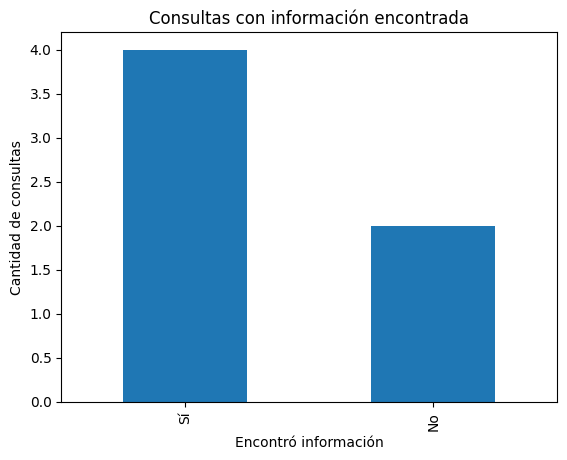

In [43]:
conteo_info = metricas["encontro_informacion"].value_counts()

conteo_info.plot(kind="bar")

plt.title("Consultas con información encontrada")
plt.xlabel("Encontró información")
plt.ylabel("Cantidad de consultas")
plt.show()

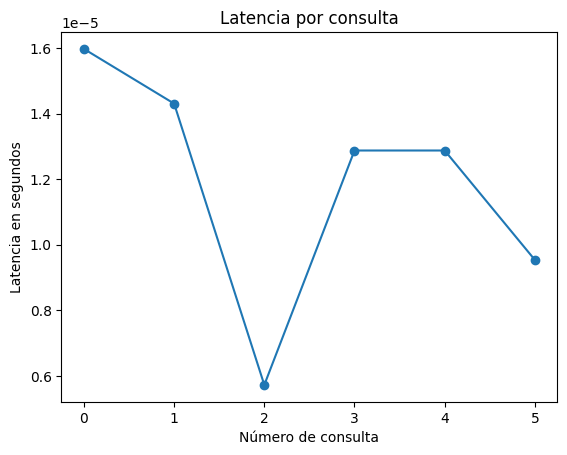

In [44]:
metricas["latencia_segundos"].plot(kind="line", marker="o")

plt.title("Latencia por consulta")
plt.xlabel("Número de consulta")
plt.ylabel("Latencia en segundos")
plt.show()

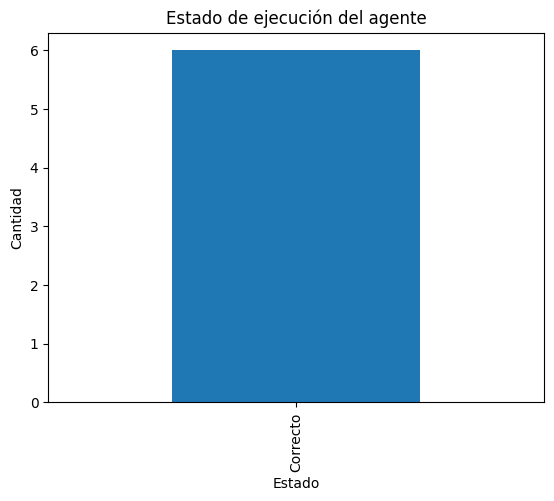

In [45]:
conteo_estado = metricas["estado"].value_counts()

conteo_estado.plot(kind="bar")

plt.title("Estado de ejecución del agente")
plt.xlabel("Estado")
plt.ylabel("Cantidad")
plt.show()


In [49]:
with open("duoc_assist_logs.txt", mode="r", encoding="utf-8") as archivo:
    logs = archivo.readlines()

for linea in logs[-10:]:
    print(linea.strip())

2026-06-25 20:15:24,196 - INFO - Latencia: 2.09808349609375e-05 segundos
2026-06-25 20:15:24,196 - INFO - Consulta realizada: ¿Dónde consulto los beneficios estudiantiles?
2026-06-25 20:15:24,196 - INFO - Respuesta generada: Los beneficios estudiantiles deben ser consultados en los canales oficiales de Duoc UC.
2026-06-25 20:15:24,196 - INFO - Latencia: 1.33514404296875e-05 segundos
2026-06-25 20:15:24,196 - INFO - Consulta realizada: ¿Cuál es el clima de hoy?
2026-06-25 20:15:24,196 - INFO - Respuesta generada: No encontré información relacionada con la consulta.
2026-06-25 20:15:24,196 - INFO - Latencia: 9.5367431640625e-06 segundos
2026-06-25 20:15:24,196 - INFO - Consulta realizada: ¿Quién ganó el mundial?
2026-06-25 20:15:24,196 - INFO - Respuesta generada: No encontré información relacionada con la consulta.
2026-06-25 20:15:24,196 - INFO - Latencia: 7.3909759521484375e-06 segundos


In [47]:
import os

logging.basicConfig(
    filename="duoc_assist_logs.txt",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

logging.info("Sistema de observabilidad iniciado correctamente")

print("Archivo de logs configurado correctamente")
print("Existe el archivo:", os.path.exists("duoc_assist_logs.txt"))

Archivo de logs configurado correctamente
Existe el archivo: True


In [50]:
errores_log = []

for linea in logs:
    if "ERROR" in linea:
        errores_log.append(linea)

print("Cantidad de errores encontrados en logs:", len(errores_log))

if len(errores_log) == 0:
    print("No se detectaron errores en los registros.")
else:
    print("Errores detectados:")
    for error in errores_log:
        print(error)

Cantidad de errores encontrados en logs: 0
No se detectaron errores en los registros.


In [51]:
def validar_consulta(pregunta):
    pregunta_normalizada = normalizar_texto(pregunta)

    palabras_sensibles = [
        "rut",
        "contraseña",
        "password",
        "clave",
        "direccion",
        "telefono"
    ]

    if len(pregunta) > 200:
        return False, "La consulta es demasiado extensa para ser procesada."

    for palabra in palabras_sensibles:
        if palabra in pregunta_normalizada:
            return False, "La consulta contiene datos sensibles y no será procesada."

    return True, "Consulta válida."

In [52]:
def ejecutar_agente_observado(pregunta):
    inicio = time.time()

    try:
        consulta_valida, mensaje_validacion = validar_consulta(pregunta)

        if consulta_valida == False:
            respuesta = mensaje_validacion
            estado = "Rechazada"
            encontro_informacion = "No"

            logging.warning(f"Consulta rechazada por seguridad: {pregunta}")

        else:
            respuesta = buscar_informacion(pregunta)

            if respuesta == "No encontré información relacionada con la consulta.":
                encontro_informacion = "No"
            else:
                encontro_informacion = "Sí"

            estado = "Correcto"

            logging.info(f"Consulta realizada: {pregunta}")
            logging.info(f"Respuesta generada: {respuesta}")

        fin = time.time()
        latencia = fin - inicio

        logging.info(f"Latencia: {latencia} segundos")

    except Exception as error:
        fin = time.time()
        latencia = fin - inicio

        respuesta = "Error al procesar la consulta."
        estado = "Error"
        encontro_informacion = "No"

        logging.error(f"Error en la consulta: {pregunta} - {error}")

    with open(nombre_archivo, mode="a", newline="", encoding="utf-8") as archivo:
        escritor = csv.writer(archivo)

        escritor.writerow([
            datetime.now(),
            pregunta,
            respuesta,
            latencia,
            estado,
            encontro_informacion
        ])

    print("Pregunta:", pregunta)
    print("Respuesta:", respuesta)
    print("Latencia:", latencia, "segundos")
    print("Estado:", estado)
    print("Encontró información:", encontro_informacion)

    return respuesta

In [53]:
ejecutar_agente_observado("Mi RUT es 12345678-9, ¿puedes guardarlo?")

Pregunta: Mi RUT es 12345678-9, ¿puedes guardarlo?
Respuesta: La consulta contiene datos sensibles y no será procesada.
Latencia: 0.00032138824462890625 segundos
Estado: Rechazada
Encontró información: No


'La consulta contiene datos sensibles y no será procesada.'

In [54]:
nombre_archivo = "metricas_duoc_assist.csv"

with open(nombre_archivo, mode="w", newline="", encoding="utf-8") as archivo:
    escritor = csv.writer(archivo)

    escritor.writerow([
        "fecha",
        "pregunta",
        "respuesta",
        "latencia_segundos",
        "estado",
        "encontro_informacion"
    ])

print("Archivo de métricas finales reiniciado correctamente")

Archivo de métricas finales reiniciado correctamente


In [55]:
preguntas_prueba_final = [
    "¿Cuál es la asistencia mínima?",
    "¿Cuándo se realiza la matrícula?",
    "¿Puedo hacer retiro de asignaturas?",
    "¿Dónde consulto los beneficios estudiantiles?",
    "¿Cuál es el clima de hoy?",
    "¿Quién ganó el mundial?",
    "Mi RUT es 12345678-9, ¿puedes guardarlo?"
]

for pregunta in preguntas_prueba_final:
    ejecutar_agente_observado(pregunta)
    print("-------------------------")

Pregunta: ¿Cuál es la asistencia mínima?
Respuesta: La asistencia mínima requerida para aprobar una asignatura es 70%.
Latencia: 0.0005428791046142578 segundos
Estado: Correcto
Encontró información: Sí
-------------------------
Pregunta: ¿Cuándo se realiza la matrícula?
Respuesta: La matrícula debe realizarse dentro de las fechas establecidas por la institución.
Latencia: 0.00020384788513183594 segundos
Estado: Correcto
Encontró información: Sí
-------------------------
Pregunta: ¿Puedo hacer retiro de asignaturas?
Respuesta: El retiro de asignaturas puede solicitarse dentro del plazo académico correspondiente.
Latencia: 0.00012493133544921875 segundos
Estado: Correcto
Encontró información: Sí
-------------------------
Pregunta: ¿Dónde consulto los beneficios estudiantiles?
Respuesta: Los beneficios estudiantiles deben ser consultados en los canales oficiales de Duoc UC.
Latencia: 0.0008740425109863281 segundos
Estado: Correcto
Encontró información: Sí
-------------------------
Pregunt

In [56]:
metricas = pd.read_csv("metricas_duoc_assist.csv")

metricas

,fecha,pregunta,respuesta,latencia_segundos,estado,encontro_informacion
0,2026-06-25 20:22:21.919008,¿Cuál es la asistencia mínima?,La asistencia mínima requerida para aprobar un...,0.000543,Correcto,Sí
1,2026-06-25 20:22:21.919588,¿Cuándo se realiza la matrícula?,La matrícula debe realizarse dentro de las fec...,0.000204,Correcto,Sí
2,2026-06-25 20:22:21.919903,¿Puedo hacer retiro de asignaturas?,El retiro de asignaturas puede solicitarse den...,0.000125,Correcto,Sí
3,2026-06-25 20:22:21.920972,¿Dónde consulto los beneficios estudiantiles?,Los beneficios estudiantiles deben ser consult...,0.000874,Correcto,Sí
4,2026-06-25 20:22:21.921293,¿Cuál es el clima de hoy?,No encontré información relacionada con la con...,0.000138,Correcto,No
5,2026-06-25 20:22:21.922231,¿Quién ganó el mundial?,No encontré información relacionada con la con...,0.000149,Correcto,No
6,2026-06-25 20:22:21.922423,"Mi RUT es 12345678-9, ¿puedes guardarlo?",La consulta contiene datos sensibles y no será...,0.000044,Rechazada,No


In [57]:
total_consultas = len(metricas)

latencia_promedio = metricas["latencia_segundos"].mean()

total_correctas = (metricas["estado"] == "Correcto").sum()

total_rechazadas = (metricas["estado"] == "Rechazada").sum()

total_errores = (metricas["estado"] == "Error").sum()

consultas_con_info = (metricas["encontro_informacion"] == "Sí").sum()

consultas_sin_info = (metricas["encontro_informacion"] == "No").sum()

print("Total de consultas:", total_consultas)
print("Latencia promedio:", latencia_promedio, "segundos")
print("Consultas correctas:", total_correctas)
print("Consultas rechazadas por seguridad:", total_rechazadas)
print("Total de errores:", total_errores)
print("Consultas con información:", consultas_con_info)
print("Consultas sin información:", consultas_sin_info)

Total de consultas: 7
Latencia promedio: 0.0002965927124023125 segundos
Consultas correctas: 6
Consultas rechazadas por seguridad: 1
Total de errores: 0
Consultas con información: 4
Consultas sin información: 3


In [58]:
comportamiento_esperado = {
    "¿Cuál es la asistencia mínima?": ("Correcto", "Sí"),
    "¿Cuándo se realiza la matrícula?": ("Correcto", "Sí"),
    "¿Puedo hacer retiro de asignaturas?": ("Correcto", "Sí"),
    "¿Dónde consulto los beneficios estudiantiles?": ("Correcto", "Sí"),
    "¿Cuál es el clima de hoy?": ("Correcto", "No"),
    "¿Quién ganó el mundial?": ("Correcto", "No"),
    "Mi RUT es 12345678-9, ¿puedes guardarlo?": ("Rechazada", "No")
}

correctas = 0
total_evaluadas = 0

for index, fila in metricas.iterrows():
    pregunta = fila["pregunta"]

    if pregunta in comportamiento_esperado:
        estado_esperado, info_esperada = comportamiento_esperado[pregunta]

        if fila["estado"] == estado_esperado and fila["encontro_informacion"] == info_esperada:
            correctas = correctas + 1

        total_evaluadas = total_evaluadas + 1

precision_final = (correctas / total_evaluadas) * 100

print("Consultas evaluadas:", total_evaluadas)
print("Comportamientos correctos:", correctas)
print("Precisión final:", precision_final, "%")

Consultas evaluadas: 7
Comportamientos correctos: 7
Precisión final: 100.0 %
